In [1]:
%matplotlib widget
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import colors
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation

import os
print("Workspace Folder:", os.getcwd()) # Gets the current working directory

import torch
from torchdiffeq import odeint
print(torch.__version__)
print(torch.version.cuda)

Workspace Folder: /media/work/docs/codes/QuCF/scripts-py/jupyter-notebooks/Stepanoff


ModuleNotFoundError: No module named 'torch'

In [3]:
path_save_ = "./results"
for ii_close in range(100):
    plt.close()

In [29]:
# --------------------------------------------------------------------------------
# --- Preparing system ---
# --------------------------------------------------------------------------------
class ODE_Stepanoff(torch.nn.Module):
    # -----------------------------------------------
    def __init__(self, alpha):
        super().__init__()
        self.alpha = alpha
        return
    # -----------------------------------------------
    def forward(self, t, x):
        alpha = self.alpha
        theta, phi = x.chunk(2, dim=1)

        dphi_dt   = alpha * (1. - torch.cos(theta - phi))
        dtheta_dt = dphi_dt + (1. - alpha) * (1. - torch.cos(phi))
        y = torch.cat([dtheta_dt, dphi_dt], dim=1)
        return y
# --------------------------------------------------------------------------------
def Stepanoff_flow(alpha, x):
    x_loc = torch.tensor(x)
    y = torch.zeros_like(x_loc)
    y[:,1] = alpha * (1. - torch.cos(x_loc[:,0] - x_loc[:,1]))
    y[:,0] = y[:,1] + (1. - alpha) * (1. - torch.cos(x_loc[:,1]))
    return y
# --------------------------------------------------------------------------------
def init_1d(kappa):
    def f(x):
        f_loc = lambda x1: np.exp(kappa * np.sin(x1/2.)**2) - 1.
        y = f_loc(x) / f_loc(np.pi)
        return y
    return f
# --------------------------------------------------------------------
def init_2d(kappa):
    vm1 = init_1d(kappa[0])
    vm2 = init_1d(kappa[1])
    def f_hat(x):
        y = vm1(x[..., 0]) * vm2(x[..., 1])
        return y
    return f_hat
# # --------------------------------------------------------------------
def vm_fourier(kappa, l):
    """Fourier coefficients of von Mises density centered at (pi, pi)."""    
    vm_hat = f2.von_mises_fourier(kappa, loc=(np.pi, np.pi))
    f_hat = vm_hat(f2.dual_group(l))
    return f_hat
# --------------------------------------------------------------------
def prepare_system_real(alpha, dt, Nx, kappa, n_iter = 40):
    f_init = init_2d((kappa, kappa))
    fn = ODE_Stepanoff(alpha)

    theta = np.linspace(0, 2*np.pi, Nx)
    x1, x2 = np.meshgrid(theta, theta)
    x = np.concatenate((x1[:, :, np.newaxis], x2[:, :, np.newaxis]), axis=2)
    x = np.reshape(x, (Nx**2, 2))

    # theta = np.linspace(0, 2*np.pi, Nx)[:-1]
    # x1, x2 = np.meshgrid(theta, theta)
    # x = np.concatenate((x1[:, :, np.newaxis], x2[:, :, np.newaxis]), axis=2)
    # x = np.reshape(x, ((Nx - 1)**2, 2))

    # --- for plotting ---
    x1 = x1 / np.pi
    x2 = x2 / np.pi
    
    # --- Stepanoff flow velocities ---
    flow = Stepanoff_flow(alpha, x)

    return fn, flow, f_init, x1, x2, x, theta
# -----------------------------------------------------------------------------------

alpha_ = np.sqrt(20)
# alpha_ = 0.4

nx_    = 10
kappa_ = 1.0
dt_    = 0.1

# --- time points for plotting ---
t_plot_ = torch.linspace(0, 4, 5)
# t_plot_ = torch.linspace(0, 6, 7)
# t_plot_ = torch.linspace(0, 6, 601)

# --- create the system of differential equations ---
Nx_  = 1 << nx_
fn_, flow_, f_init_, x1_, x2_, x_, theta_ = prepare_system_real(alpha_, dt_, Nx_, kappa_)

In [30]:
# --------------------------------------------------------------------
# --- Computation ---
# --------------------------------------------------------------------

# --- propagate the angles following the Stepanoff flow ---
x_res_ = odeint(fn_, torch.tensor(x_), t_plot_, method='dopri5')

# --- find the resulting distribution of the angles ---
y_res_ = f_init_(x_res_.numpy())

max init value = 1.000e+00


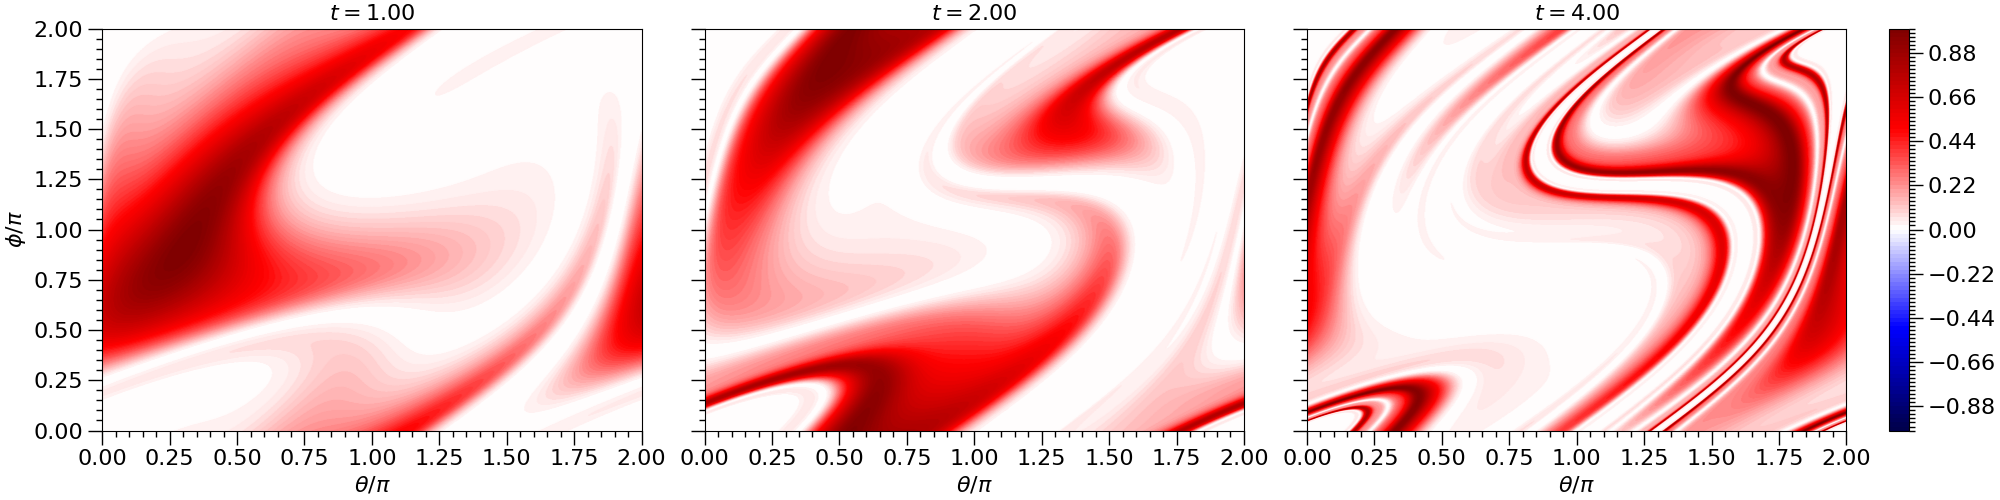

In [31]:
# --------------------------------------------------------------------------------
# --- Plotting ---
# --------------------------------------------------------------------------------
def plotting_results(fx_arr, x1, x2, Nx, t_arr, id_plot, flag_smooth):
    fx = fx_arr[id_plot]
    t  = t_arr[id_plot]

    cmap = plt.get_cmap("seismic")
    fx_max = np.max(fx)
    levels = np.linspace(-fx_max, fx_max, 101) 
    divnorm = colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

    # divnorm = mpl.colors.TwoSlopeNorm(vmin=plt_range[0], vmax=plt_range[1], vcenter=0)
    fig, ax = plt.subplots()
    # fx = np.reshape(fx, (Nx - 1, Nx - 1)) 
    fx = np.reshape(fx, (Nx, Nx)) 

    ax.cla()

    if flag_smooth:
        cs = ax.pcolormesh(x1, x2, fx, cmap=cmap, norm=divnorm, shading='gouraud')
    else:
        cs = ax.pcolormesh(x1, x2, fx, cmap=cmap, norm=divnorm)
    # cs = ax.contourf(x1, x2, fx, cmap=cmap, levels = 100, norm=divnorm)

    cb = fig.colorbar(cs, ax = ax)
    cb.ax.ticklabel_format(style="scientific")

    ax.set_xlabel('$\\theta_1/\\pi$')
    ax.set_ylabel('$\\theta_2/\\pi$')
    ax.set_title(f"Stepanoff flow; $t = {t:.2f}$")
    plt.show()

    return
# ------------------------------------------------------------------------------
def plotting_results_fancy(fx_arr, x1, x2, Nx, t_arr, ids_plot, fontsize = 16):
    N_plots = len(ids_plot)

    cmap = plt.get_cmap("seismic")
    fx_max = np.max(fx_arr[0])  # the initial conditions are taken as the renference case
    levels = np.linspace(-fx_max, fx_max, 101) 
    divnorm = colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

    print("max init value = {:0.3e}".format(fx_max))

    cs_arr = [None] * N_plots
    fig, axes = plt.subplots(1, N_plots, figsize=(20, 5), constrained_layout=True)
    for ii in range(N_plots):
        fx = fx_arr[ids_plot[ii]]
        t  = t_arr[ids_plot[ii]]
        fx = np.reshape(fx, (Nx, Nx)) 

        title_str = "t = {:0.2f}".format(t)
        title_str = r"${:s}$".format(title_str)

        ax = axes[ii]

        coef_ch = 1.0
        # if ii == 1:
        #     coef_ch *= 0.1

        if ii > 0:
            ax.set_yticklabels([])

        cs_arr[ii] = ax.pcolormesh(x1, x2, coef_ch * fx, cmap=cmap, norm=divnorm, shading='gouraud')

        ax.set_xlabel(r'$\theta/\pi$', fontsize = fontsize) 
        ax.set_title(title_str, fontsize = fontsize)
        ax.tick_params(axis="both", labelsize = fontsize, size=10, width=1)

        ax.minorticks_on()
        ax.tick_params(axis="both", which="minor", size=4, width=1)

    axes[0].set_ylabel(r'$\phi/\pi$', fontsize = fontsize)
    
    cb = fig.colorbar(cs_arr[-1], ax = axes, pad=0.01)
    cb.ax.ticklabel_format(style="scientific")
    cb.ax.tick_params(labelsize = fontsize, which="major", size=10, width=1)
    cb.ax.tick_params(which="minor", size=4, width=1)
    plt.show()
    return
# --------------------------------------------------------------------------------
# plotting_results_fancy(y_res_, x1_, x2_, Nx_, t_plot_, [0, 1, 2, 4])
# plotting_results_fancy(y_res_, x1_, x2_, Nx_, t_plot_, [5,6])

plotting_results_fancy(y_res_, x1_, x2_, Nx_, t_plot_, [1, 2, 4])

# flag_smooth = True
# for ii_plot in [0, 1, 2, 4]:
#     plotting_results(y_res_, x1_, x2_, Nx_, t_plot_, ii_plot, flag_smooth)
# del ii_plot, flag_smooth

In [32]:
# --------------------------------------------------------------------------------
# --- Saving data to an .hdf5 file ---
# --------------------------------------------------------------------------------
import h5py
def form_file_name(alpha, kappa, nx):
    file_name = "new_Stepanoff_data_k{:0.1f}_a{:0.3f}_n{:d}.hdf5".format(kappa, alpha, nx)
    return file_name
# -----------------------------------------------------------------------------------
def save_data_hdf5(fx_arr, t_arr, theta, nx, alpha, kappa, path_root):
    file_name = form_file_name(alpha, kappa, nx)
    full_fname = path_root + "/" + file_name

    print(">>> Storing the coefficients into the folder:\n " + path_root)
    print(">>> into the file: " + file_name)

    N_data = len(fx_arr)
    with h5py.File(full_fname, "w") as f:
        grp = f.create_group("basic")
        grp.create_dataset('nx',     data=int(nx))
        grp.create_dataset('alpha',  data=float(alpha))
        grp.create_dataset('kappa',  data=float(kappa))
        grp.create_dataset('N_data', data=int(N_data))
        grp.create_dataset('theta',  data=theta)

        for id_data in range(N_data):
            grp = f.create_group("data_{:d}".format(id_data))
            fx = fx_arr[id_data]
            t  = t_arr[id_data]
            grp.create_dataset('fx',  data = fx)
            grp.create_dataset('t',   data = float(t))
    return
# --------------------------------------------------------------------------------
save_data_hdf5(y_res_, t_plot_, theta_, nx_, alpha_, kappa_, path_save_)

>>> Storing the coefficients into the folder:
 ./results
>>> into the file: new_Stepanoff_data_k1.0_a4.472_n10.hdf5


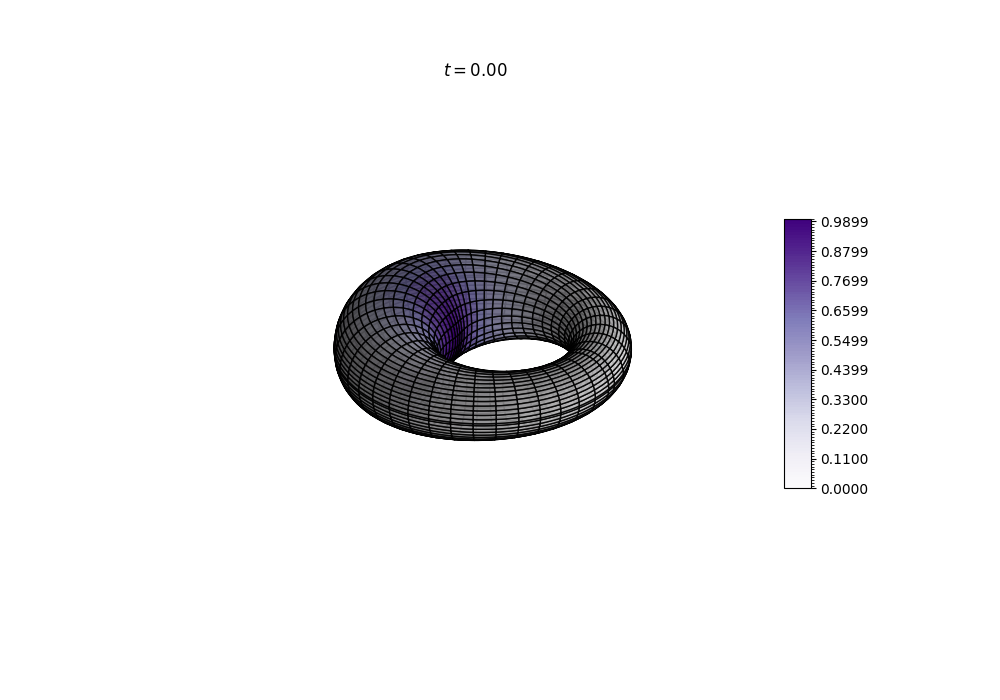

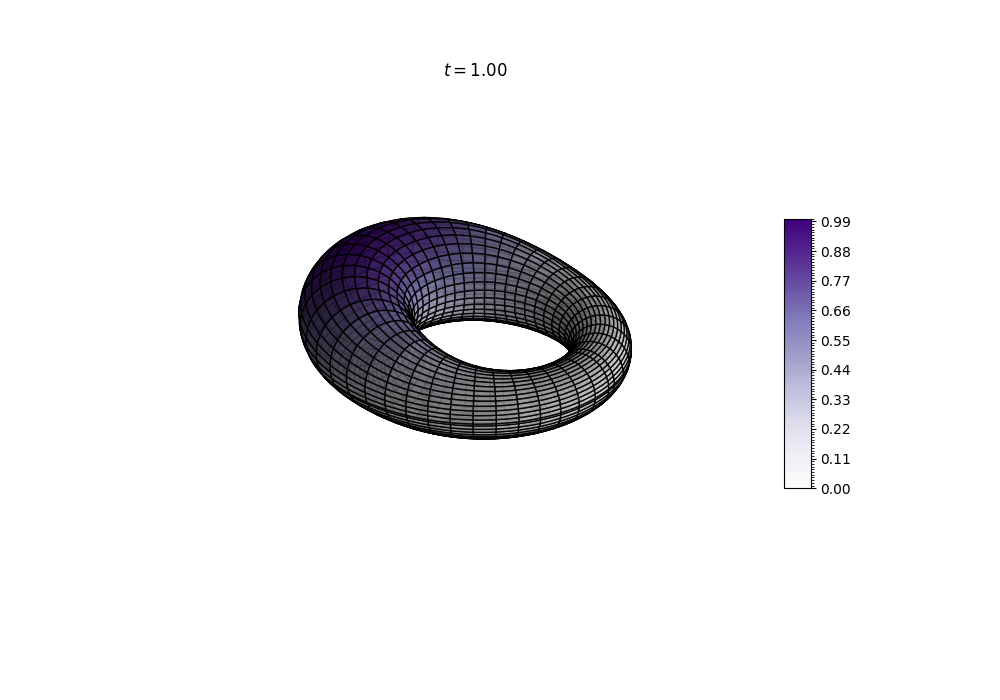

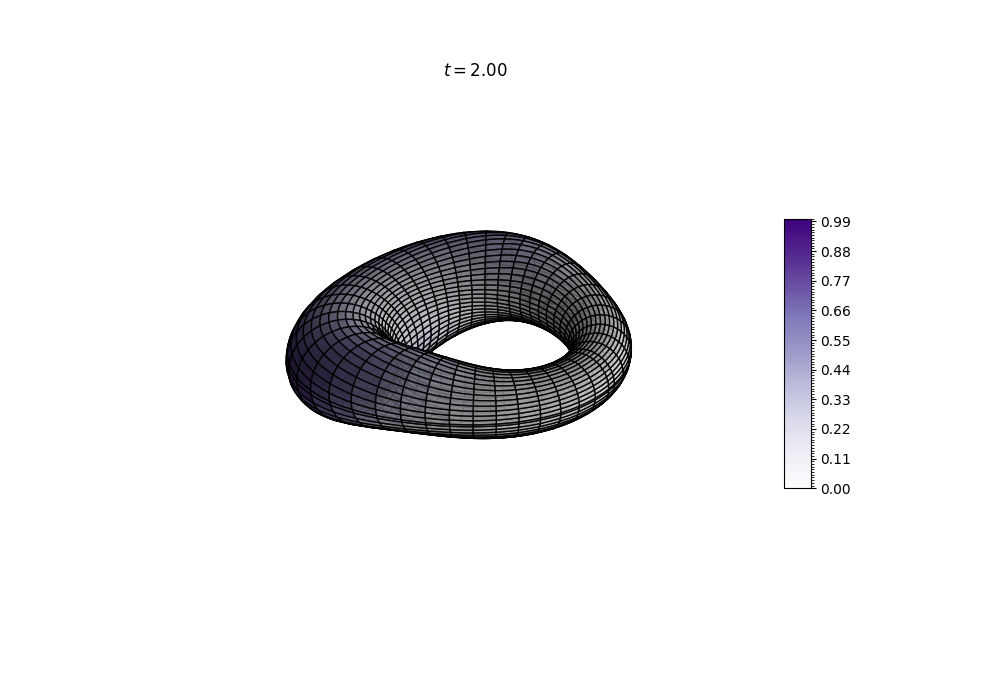

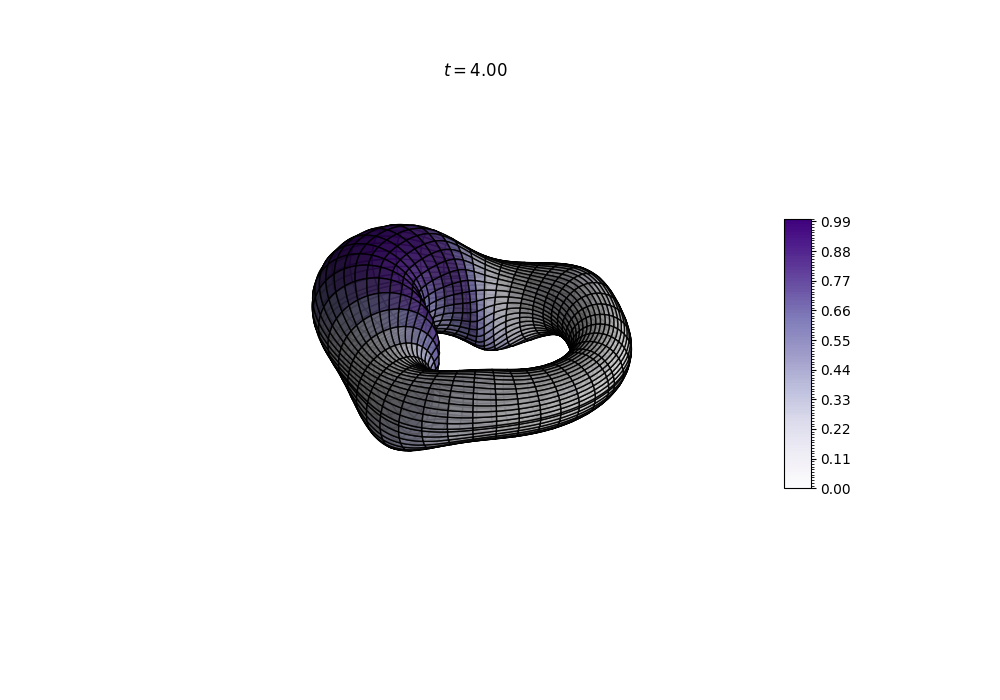

In [21]:
# --------------------------------------------------------------------------------
# --- 3D Plotting ---
# --------------------------------------------------------------------------------
def plot_torus(fx_arr, x1, x2, Nx, t_arr, ids_plot, fontsize = 16):
    N_plots = len(ids_plot)

    # Define torus parameters
    R = 2  
    r = 0.5  
    theta = x1 * np.pi
    phi   = x2 * np.pi


    for ii in range(N_plots):
        t  = t_arr[ids_plot[ii]]
        fx = fx_arr[ids_plot[ii]]
        fx = np.reshape(fx, (Nx, Nx)) 

        # Compute perturbed minor radius
        r_perturbed = r + fx

        # colormap
        cmap = plt.get_cmap("seismic")
        cmap = plt.get_cmap("Greys")
        cmap = plt.get_cmap("ocean")
        cmap = plt.get_cmap("Purples")

        # fx_max = np.max(fx)  
        # levels = np.linspace(- fx_max, fx_max, 101) 
        levels = np.linspace(np.min(fx), np.max(fx), 101) 
        divnorm = colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

        cmap_map = plt.cm.ScalarMappable(cmap=cmap, norm=divnorm)
        cmap_map.set_array([])  # Set perturbation values for colorbar

        # Compute the original torus 
        X_orig = (R + r * np.cos(theta)) * np.cos(phi)
        Y_orig = (R + r * np.cos(theta)) * np.sin(phi)
        Z_orig = r * np.sin(theta)

        # Compute the perturbed torus
        X_pert = (R + r_perturbed * np.cos(theta)) * np.cos(phi)
        Y_pert = (R + r_perturbed * np.cos(theta)) * np.sin(phi)
        Z_pert = r_perturbed * np.sin(theta)

        # Plot the torus
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')

        # Plot original torus (semi-transparent)
        # ax.plot_surface(X_orig, Y_orig, Z_orig, color='green')

        # # Plot perturbed torus (solid)
        # surf = ax.plot_surface(X_pert, Y_pert, Z_pert, cmap=cmap, norm=divnorm, alpha=0.9, edgecolor='k')
        surf = ax.plot_surface(X_pert, Y_pert, Z_pert, facecolors=cmap(divnorm(fx)), alpha=0.9, edgecolor='k')

        # colorbar
        cb = fig.colorbar(cmap_map, ax=ax, shrink=0.5, aspect=10)
        # cb = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
        cb.ax.ticklabel_format(style="scientific")

        # Set aspect ratio to be equal
        ax.set_box_aspect([1, 1, 1])  # Ensure equal scaling

        # Adjust axis limits to be equal
        max_range = max(R + r + 0.2, R - r - 0.2)
        ax.set_xlim(-max_range, max_range)
        ax.set_ylim(-max_range, max_range)
        ax.set_zlim(-max_range, max_range)

        # Remove axis box and grid
        ax.set_axis_off()

        # title
        title_str = "t = {:0.2f}".format(t)
        title_str = r"${:s}$".format(title_str)
        plt.title(title_str)
        plt.show()
    return
# ---------------------------------------------------------------------------------------------
plot_torus(y_res_, x1_, x2_, Nx_, t_plot_, [0, 1, 2, 4])

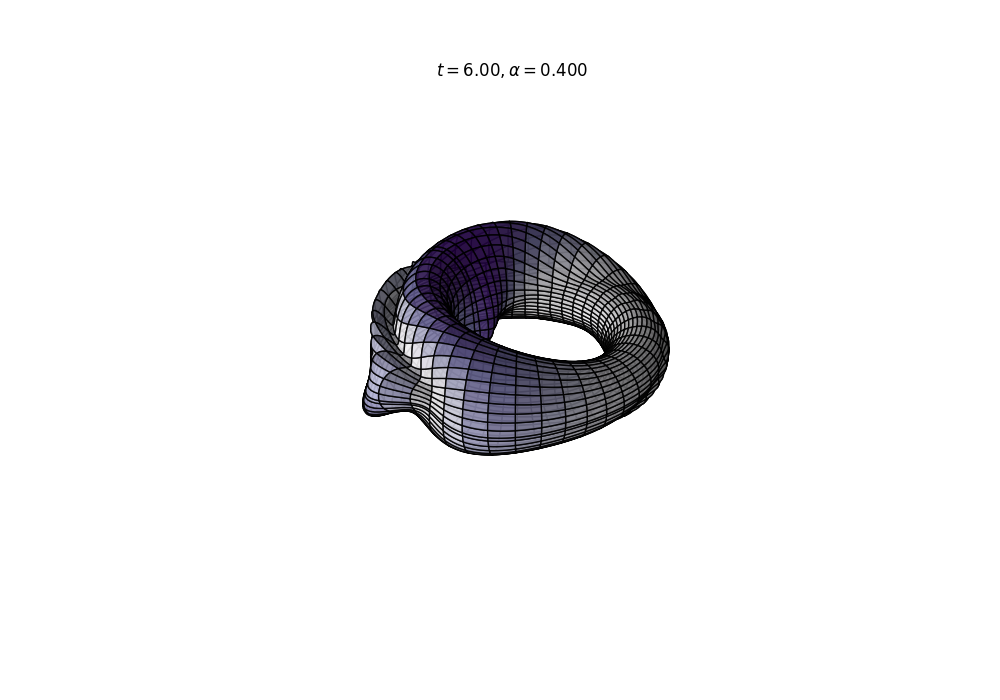

In [34]:
# --------------------------------------------------------------------------------
# --- Video of the 3D perturbation ---
# --------------------------------------------------------------------------------
def create_video_3d(fx_arr, x1, x2, Nx, t_arr, fontsize = 16):
    def update(frame):
        # --- Clear previous frame ---
        ax.clear()  

        # --- Compute perturbed minor radius ---
        fx = np.reshape(fx_arr[frame], (Nx, Nx))
        r_perturbed = r + fx 

        # --- Compute the perturbed torus ---
        X_pert = (R + r_perturbed * np.cos(theta)) * np.cos(phi)
        Y_pert = (R + r_perturbed * np.cos(theta)) * np.sin(phi)
        Z_pert = r_perturbed * np.sin(theta)

        # --- plotting ---
        surf = ax.plot_surface(X_pert, Y_pert, Z_pert, facecolors=cmap(divnorm(fx)), alpha=0.9, edgecolor='k')

        # # --- colorbar ---
        # cb = fig.colorbar(cmap_map, ax=ax, shrink=0.5, aspect=10)
        # cb.ax.ticklabel_format(style="scientific")

        # --- Set aspect ratio to be equal ---
        ax.set_box_aspect([1, 1, 1])

        # Adjust axis limits
        max_range = max(R + r + 0.2, R - r - 0.2)
        ax.set_xlim(-max_range, max_range)
        ax.set_ylim(-max_range, max_range)
        ax.set_zlim(-max_range, max_range)

        # Rotate the view for a dynamic effect
        ax.view_init(elev=30, azim=frame * 2)

        # Remove axes for clean visualization
        ax.set_axis_off()

        # title
        title_str = "t = {:0.2f}, \\alpha = {:0.3f}".format(t_arr[frame], alpha_)
        title_str = r"${:s}$".format(title_str)
        ax.set_title(title_str)

        return surf,
    # -----------------------------------------------------------------
    N_steps = len(fx_arr)
    fx_ref = fx_arr[0]

    # Define torus parameters
    R = 2  
    r = 0.5  
    theta = x1 * np.pi
    phi   = x2 * np.pi

    # --- Create the figure ---
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # --- colormap ---
    cmap = plt.get_cmap("Purples")
    levels = np.linspace(np.min(fx_ref), np.max(fx_ref), 101) 
    divnorm = colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)
    cmap_map = plt.cm.ScalarMappable(cmap=cmap, norm=divnorm)
    cmap_map.set_array([])  # Set perturbation values for colorbar

    # --- Create animation ---
    ani = animation.FuncAnimation(
        fig, update, 
        frames=N_steps, 
        interval=500, # each frame is displayed for "interval" miliseconds
        blit=False
    )

    # --- Save animation as video (MP4) ---
    video_filename = "Stepanoff_torus.mp4"
    writer = animation.FFMpegWriter(fps=30, bitrate=1800)
    ani.save(video_filename, writer=writer)
    return
# -----------------------------------------------------------------
create_video_3d(y_res_, x1_, x2_, Nx_, t_plot_)

In [ ]:
# -------------------------------------------------------------------
# --- Testing composition of functions ---
# -------------------------------------------------------------------
import numpy as np
from more_itertools import take

# -------------------------------------------------------------------
def orbit(f, u):
    """Orbit of a point under iterated application of a map."""
    f_next = f
    while True:
        yield f_next
        f_next = u(f_next)
# iter 0: f(x)
# iter 1: u(f(x)) = f(g(x))
# iter 2: u[u(f(x))] = u[f(g(x))] = f(g(g(x)))
# -------------------------------------------------------------------
def u(g):  # compose
    def u_loc(f):
        h = lambda x: f(g(x))
        return h
    return u_loc
# -------------------------------------------------------------------
def f_init(x):
    return np.sum(x)
# -------------------------------------------------------------------
def g_flow(x):
    return x + 1.
# -------------------------------------------------------------------

x = np.array([0.,0.])
print(g_flow(x))

u_prop = u(g_flow)
f_orb = orbit(f_init, u_prop)
fn = take(11, f_orb)

print(fn[0](x))
print(fn[1](x))
print(fn[2](x))

[1. 1.]
0.0
2.0
4.0


In [ ]:
# -------------------------------------------------------------------
# --- Testing the map function ---
# -------------------------------------------------------------------
xx = np.array([[0, 1, 2], [10, 20, 30]])

print(
    list(map(
        lambda x: 2*x, 
        xx
    ))
)

[array([0, 2, 4]), array([20, 40, 60])]


In [ ]:
# -------------------------------------------------------------------
# --- Testing the chunk and cat function ---
# -------------------------------------------------------------------
xx = torch.tensor([
    [1, 10],
    [2, 20],
    [3, 30],
    [4, 40],
])

yy1, yy2 = xx.chunk(2, dim=1)
print(yy1)
print(yy2)

yy3 = torch.cat([yy1, yy2], dim = 1)
print(yy3)



tensor([[1],
        [2],
        [3],
        [4]])
tensor([[10],
        [20],
        [30],
        [40]])
tensor([[ 1, 10],
        [ 2, 20],
        [ 3, 30],
        [ 4, 40]])
